In [1]:
import numpy as np

In [14]:
final_time = 300
num_nodes1 = 500
num_nodes2 = 5000
alphas =  np.array([0.5,0.3,0.2]) 
comm_size1 = (num_nodes1 * alphas).astype(int)
comm_size2 = (num_nodes2 * alphas).astype(int)

#Dissociative
# prob_matrix = np.array([[0.1, 0.9, 0.7],
#                                [0.9, 0.1, 0.9],
#                                [0.7, 0.9, 0.1]])

#Assertative
prob_matrix = np.array([[0.9, 0.2, 0.1],
                               [0.2, 0.9, 0.3],
                               [0.1, 0.3, 0.9]])

In [15]:
#Helper functions

def dirac_delta(x,y):
    " Dirac delta function "
    if x == y:
        return 1
    else:
        return 0


def plug_in_prob_matrix(adj_matrix, labs, comm_sizes):
    " Compute plug-in estimate of the probability matrix from adjacency matrix and community labels"
    A = np.asarray(adj_matrix)
    labs = np.asarray(labs)
    K = len(comm_sizes)

    # initialize plug-in probability matrix
    prob_matrix = np.zeros((K, K), dtype=float)

    # loop over all community pairs (ℓ, h)
    for l in range(K):
        nodes_l = np.where(labs == l)[0]
        for h in range(K):
            nodes_h = np.where(labs == h)[0]

            # sum over all edges j→i with i∈l, j∈h
            total_edges = 0.0
            for i in nodes_l:
                for j in nodes_h:
                    total_edges += A[i, j]

            # divide by product of community sizes
            if comm_sizes[l] > 0 and comm_sizes[h] > 0:
                prob_matrix[l, h] = total_edges / (comm_sizes[l] * comm_sizes[h])
            
            
            else:
                prob_matrix[l, h] = 0.0
    return prob_matrix


In [16]:
def generate_sbm_adjacency_matrix(community_sizes, probability_matrix):

    # Calculate the total number of nodes
    num_nodes = sum(community_sizes)
    adjacency_matrix = np.zeros((num_nodes, num_nodes))
    community_labels = [c for c, size in enumerate(community_sizes) for _ in range(size)]
    
    for i in range(num_nodes):
        for j in range(num_nodes):
            prob = probability_matrix[community_labels[i], community_labels[j]]
            # Add an edge with probability `prob`
            if np.random.rand() < prob:
                adjacency_matrix[i, j] = 1

    return community_labels, adjacency_matrix

In [17]:
labs, adj_matrix = generate_sbm_adjacency_matrix(comm_size1, prob_matrix)
estimated_prob_matrix = plug_in_prob_matrix(adj_matrix, labs, comm_size1)

print(estimated_prob_matrix)
print(prob_matrix)


[[0.899472   0.19765333 0.10104   ]
 [0.19989333 0.89866667 0.29853333]
 [0.099      0.2944     0.9014    ]]
[[0.9 0.2 0.1]
 [0.2 0.9 0.3]
 [0.1 0.3 0.9]]


In [18]:
# # Define excitation function psi using a modified log-sum-exp function with clipping to avoid overflow
# def psi(x):
#     return np.clip(np.log(1 + np.exp(x)), None, 40)

def psi(x):
    return x


#Redefine poisson_randomness function to take E as an argument
def poisson_randomness(lmbd, E):
    i = 0
    S = 0  
    while S <= lmbd:  
        i += 1
        S += E[i]  
    return i - 1 


def simulate_comb_sbm(E, T, num_nodes, comm_size, kernel_function_matrix, kernel_params_matrix, G, labs,  mu_vector = np.array([0.5, 0.5, 0.5])):
    num_comm = len(comm_size)
    t_values = np.arange(T, 0, -1)

    #Compute a matrix of kernel_valuesa at times 0:T for all nodes
    kernel_values = np.zeros((T, num_nodes))
    for i in range(num_nodes):
       # for j in range(num_nodes):
        kernel_function = kernel_function_matrix[labs[i]]
        kernel_params = kernel_params_matrix[labs[i]]
        kernel_values[:, i] = kernel_function(kernel_params, t_values)

    if len(mu_vector) != comm_size.shape[0]:
        raise ValueError("The length of mu_vector must match the number of communities in comm_size.")

    mu_vector_expanded = np.zeros(num_nodes)
    mu_vector_expanded = mu_vector[labs]

    # Initializing the matrices
    N = np.zeros((T, num_nodes))
    lmbd = np.zeros((T, num_nodes))
    X = np.zeros((T, num_nodes))

    #Settting initial values for lambda and counts
    lmbd[0, :] = psi(mu_vector_expanded)
    X[0, :] = np.zeros(num_nodes)
    
    for i in range(1, T):
        for j in range(num_nodes):
            lmbd[i, j] = psi(mu_vector_expanded[j] + np.dot(G[j, :], np.sum(kernel_values[T-i:, :] * X[:i, :], axis=0)) / num_nodes)
            X[i, j] = poisson_randomness(lmbd[i, j],E[i,j, :])
            N[i, j] = N[i-1, j] + X[i, j]

    return N, lmbd, X, kernel_values


def simulate_mf_sbm(E, T, comm_size, prob_matrix, kernel_function_matrix, kernel_params_matrix, mu_vector = np.array([0.5, 0.5, 0.5])):
    num_comm = len(comm_size)
    num_nodes = np.sum(comm_size)
    alphas = comm_size/np.sum(comm_size)
    t_values = np.arange(T,0, -1)
    
    kernel_values = np.zeros((T, num_comm))
    for i in range(num_comm):
        # for j in range(num_comm):
        kernel_function = kernel_function_matrix[i]
        kernel_params = kernel_params_matrix[i]
        kernel_values[:, i] = kernel_function(kernel_params, t_values)


    # Initialize vectors to store values for the simulation
    N = np.zeros((T, num_nodes))
    lmbd = np.zeros((T, num_comm))
    X = np.zeros((T, num_nodes))   

    # Set initial values for lambda and counts
    X[0, :] = np.zeros(num_nodes)
    N[0, :] = X[0, :]
    lmbd[0, :] = psi(mu_vector)

    # Run the simulation for each time step
    for i in range(1, T):
        for j in range(num_comm):
            lmbd[i, j] = psi(mu_vector[j] + np.dot(alphas* prob_matrix[:,j], np.sum(kernel_values[T-i:,:] * lmbd[:i,:], axis = 0)))
            print(lmbd[:i,:])
            print(kernel_values[T-i:,:])
            size = comm_size[j]

            for k in range(size):
                # Simulate the Poisson process for the current time step
                X[i,k] = poisson_randomness(lmbd[i,j],  E[i, j, :])
            
                # Update the cumulative count of events
                N[i,k] = N[i - 1, j] + X[i, j]

    return N, lmbd, X, kernel_values

In [19]:
def exponential_kernel(kernel_params, t):
    alpha, beta = kernel_params
    return alpha * np.exp(-beta * t)

def power_law_kernel(kernel_params, t):
    alpha, beta = kernel_params
    return alpha / (1+ t ** (beta))

def rayleigh_kernel(kernel_params, t):
    alpha, beta = kernel_params
    return alpha * t * np.exp(-beta * t**2)

def gaussian_kernel(kernel_params, t):
    alpha, beta = kernel_params
    return alpha * np.exp(-0.5 * ((t - beta) ** 2))

def sigmoid_kernel(kernel_params, t):
    alpha, beta = kernel_params
    return np.tanh(alpha * t + beta)

In [20]:
power_params =  [0.9, 2.5]
ray_params = [0.5, 1.0]
exp_params = [0.9, 0.5]


exp_params1 =  [1.5, 10]
exp_params2 = [1.5,2]
exp_params3 = [1.5, 0.5]

kernel_params_matrix = np.array([exp_params1, exp_params2, exp_params3])
#kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_function_matrix = np.array([exponential_kernel, exponential_kernel, exponential_kernel])

E = np.random.exponential(scale = 1.0, size = (final_time, num_nodes1, 100))
N_comb, lmbd_comb ,X_comb, kernel_values = simulate_comb_sbm(E, final_time,num_nodes1,comm_size1, kernel_function_matrix, kernel_params_matrix, adj_matrix, labs)

### Approach one inference functions

In [21]:
def jumps_per_community_over_time(labs, X):
    labs = np.asarray(labs)
    num_communities = np.max(labs) + 1
    one_hot = np.eye(num_communities)[labs]  # shape (N, num_communities)
    return X @ one_hot  # shape (T, num_communities)

In [22]:
num_comm = len(comm_size1)
Y = jumps_per_community_over_time(labs, X_comb)

In [23]:
def grad_loglik_intuitive(labs, comm_sizes, X, lambda_bar, grad_lambda_bar):
    """
    Clear, step-by-step computation of:
        ∇_θ ℓ(θ) ≈ Σ_{h,t} [ ( Y_t^h (2 - λ̄_t^h) / Ā^h - n^h ) * ∇_θ λ̄_t^h ]

    Returns
    -------
    grad : (P,) ndarray
    """
    labs = np.asarray(labs)
    X = np.asarray(X)
    lambda_bar = np.asarray(lambda_bar)           # (T, q)
    grad_lambda_bar = np.asarray(grad_lambda_bar) # (T, q, num_params)

    T, N = X.shape
    num_comm = lambda_bar.shape[1]
    num_params = grad_lambda_bar.shape[2]

    # Y_t^h: jumps per community/time
    Y = jumps_per_community_over_time(labs, X)  # (T, q)

    # Ā^h: mean over time of Y_t^h
    Abar = Y.mean(axis=0)/comm_sizes # (T, q)

    grad = np.zeros(num_params, dtype=float)

    # Loops for clarity
    for h in range(num_comm):
        n_h = comm_sizes[h]
        for t in range(T):
            Abar_h = Abar[h]
            Y_t_h = Y[t, h]
            lmb_t_h = lambda_bar[t, h]
            # safe handling when Ā^h == 0
            if Abar_h > 0:
                coeff = Y_t_h * (2.0 - lmb_t_h) / Abar_h - n_h
            else:
                coeff = -n_h
            grad += coeff * grad_lambda_bar[t, h, :]

    return grad

In [24]:
def grad_loglik_fast(labs, comm_sizes, X, lambda_bar, grad_lambda_bar):
    """
    Vectorized version of:
        ∇_θ ℓ(θ) ≈ Σ_{h,t} [ ( Y_t^h (2 - λ̄_t^h) / Ā_t^h - n^h ) * ∇_θ λ̄_t^h ]

    Shapes
    ------
    labs            : (N,)
    comm_sizes      : (q,)
    X               : (T, N)
    lambda_bar      : (T, q)
    grad_lambda_bar : (T, q, P)

    Returns
    -------
    grad : (P,) ndarray
    """

    labs = np.asarray(labs)
    comm_sizes = np.asarray(comm_sizes)
    X = np.asarray(X)
    lambda_bar = np.asarray(lambda_bar)           # (T, q)
    grad_lambda_bar = np.asarray(grad_lambda_bar) # (T, q, P)

    T, N = X.shape
    T_l, q = lambda_bar.shape
    T_g, q_g, P = grad_lambda_bar.shape

    assert T_l == T and T_g == T, "Time dimension T must match."
    assert q_g == q, "Community count q must match."
    assert comm_sizes.shape[0] == q, "comm_sizes must have length q."

    # Y_t^h: jumps per community/time, shape (T, q)
    Y = jumps_per_community_over_time(labs, X)

    # Ā_t^h: your current code uses cumulative sum over time, divided by T
    # (T, q). This preserves the original semantics.
    Abar = Y.mean(axis=0)/comm_sizes

    # Build coeff[t, h] = Y_t^h (2 - λ̄_t^h) / Ā_t^h - n^h  (if Abar_t^h > 0)
    #                   = -n^h                              (otherwise)

    # Broadcast comm_sizes to (T, q)
    n = comm_sizes.reshape(1, q)              # (1, q)
    coeff = -np.broadcast_to(n, Y.shape).astype(float)  # (T, q), start with -n^h

    # Mask where Abar_t^h > 0
    mask = Abar > 0

    # Add the Y*(2-λ)/Abar term only where Abar > 0
    coeff[mask] += (
        Y[mask] * (2.0 - lambda_bar[mask]) / Abar[mask]
    )

    # Now grad = Σ_{t,h} coeff[t,h] * grad_lambda_bar[t,h,:]
    # Use einsum to contract over t and h
    grad = np.einsum('tq,tqp->p', coeff, grad_lambda_bar)

    return grad


In [25]:

# N = 5 nodes, two communities 0 and 1
labs = np.array([0, 1, 0, 1, 0])     # shape (N,)
comm_sizes = np.array([3, 2])        # shape (q,)

# X: (T, N) jump matrix
X = np.array([
    [0, 1, 0, 1, 0],   # t = 0
    [1, 0, 1, 0, 0],   # t = 1
    [0, 0, 1, 1, 0],   # t = 2
])

# lambda_bar: (T, q)
lambda_bar = np.array([
    [0.2, 0.4],   # t = 0
    [0.3, 0.5],   # t = 1
    [0.4, 0.6],   # t = 2
])

# grad_lambda_bar: (T, q, P)
grad_lambda_bar = np.array([

    # t = 0
    [[0.1, 0.0, 0.2, 0.0],   # community 0
     [0.0, 0.3, 0.1, 0.2]],  # community 1

    # t = 1
    [[0.2, 0.1, 0.0, 0.3],   # community 0
     [0.1, 0.0, 0.1, 0.0]],  # community 1

    # t = 2
    [[0.0, 0.2, 0.1, 0.1],   # community 0
     [0.3, 0.1, 0.0, 0.2]],  # community 1
])


grad_intuitive = grad_loglik_intuitive(labs, comm_sizes, X, lambda_bar, grad_lambda_bar)
grad_fast = grad_loglik_fast(labs, comm_sizes, X, lambda_bar, grad_lambda_bar)
print("Gradient (intuitive):", grad_intuitive)
print("Gradient (fast):     ", grad_fast)

IndexError: boolean index did not match indexed array along axis 0; size of axis is 3 but size of corresponding boolean axis is 2

In [26]:
def padding(phi, T):
    p, _, _ = phi.shape
    T = final_time
    pad_width = ((0, T - p), (0, 0), (0, 0), )   # pad only last axis
    if T > p:
        phi = np.pad(phi, pad_width, mode="constant", constant_values=0)
    return phi

In [27]:
def lambda_bar_and_grad_for_all_times(mu,phi, alpha, prob_matrix, comm_sizes, p, T):
    """
    Compute λ̄_t^h and its gradients wrt μ^r and φ^{sr}_m,
    for t = 1,...,T (stored at index t-1).

    Parameters
    ----------
    theta       : (num_comm + num_comm*num_comm*p,) parameter vector
    alpha       : (num_comm,)
    prob_matrix : (num_comm, num_comm)  p_{l -> h}
    comm_sizes  : (num_comm,)  (used only to get num_comm)
    p           : max lag for φ^{hl}_m
    T           : number of time steps

    Returns
    -------
    lambda_bar      : (T, num_comm)
    grad_lambda_bar : (T, num_comm, num_params)
    """

    # number of communities
    num_comm = len(comm_sizes)

    # unpack parameters
    # mu = np.asarray(theta[:num_comm])
    # phi_flat = np.asarray(theta[num_comm:])
    # assert phi_flat.size == num_comm * num_comm * p

    # # φ[h, l, m-1] = φ^{hl}_m
    # phi = phi_flat.reshape(num_comm, num_comm, p)
    # pad_width = ((0, 0), (0, 0), (0, T - p))   # pad only last axis
    # if T > p:
    #     phi = np.pad(phi, pad_width, mode="constant", constant_values=0)

    phi = padding(phi, T)
    alpha = np.asarray(alpha)
    prob_matrix = np.asarray(prob_matrix)

    # parameter layout
    num_mu = num_comm
    num_phi = num_comm * num_comm * p
    num_params = num_mu + num_phi

    # storage for λ̄_t and ∂λ̄_t
    lambda_bar = np.zeros((T, num_comm))
    grad_lambda_bar = np.zeros((T, num_comm, num_params))

    # ---------------------------
    # t = 1 case
    # ---------------------------
    # λ̄_1^h = μ^h
    lambda_bar[0, :] = mu

    # ∂λ̄_1^h / ∂μ^r = δ_{hr}, rest = 0
    for h in range(num_comm):
        grad_lambda_bar[0, h, h] = 1.0

    # ---------------------------
    # t = 2,...,T
    # ---------------------------
    for tau in range(1, T):                # tau = t-1
        # ---------------------------
        # compute λ̄_t^h
        # ---------------------------
        for h in range(num_comm):
            lambda_bar[tau, h] = mu[h] + np.dot(alpha * prob_matrix[:, h], np.sum(phi[:tau, :, h][::-1, :] * lambda_bar[:tau, :] , axis=0))
            # print(lambda_bar[:tau, :])
            # print(phi[:tau, h, :])

    # ---------------------------
        # compute ∂λ̄_t^h / ∂μ^r
        # ---------------------------

            for r in range(num_comm):
                base = dirac_delta(h, r)
                rec = np.dot(alpha * prob_matrix[:, h], np.sum(phi[:tau, :, h][::-1, :] * grad_lambda_bar[:tau, :, r] , axis=0))
                grad_lambda_bar[tau, h, r] = base + rec


                # ---------------------------
                # # compute ∂λ̄_t^h / ∂φ^{sr}_m
                # # ---------------------------

            for s in range(num_comm):      # destination index of φ^{sr}_m
                for r in range(num_comm):  # source index of φ^{sr}_m
                    for m in range(1, p + 1):  # lag index (only m <= p are parameters)
                            param_idx = num_mu + (s * num_comm + r) * p + (m - 1)
                            #print(param_idx)

                            # ----- base term: δ_{hs} α_r p_{r→s} λ̄_{t+1-m}^r -----
                            if h == s and tau - m >= 0:
                                base = alpha[r] * prob_matrix[r, s] * lambda_bar[tau - m, r]
                            else:
                                base = 0.0
                
                            rec = np.dot(alpha * prob_matrix[:,h], np.sum(phi[:tau, h, :][::-1, :] * grad_lambda_bar[:tau, :, param_idx] , axis=0))
                                    # phi_time_idx = tau - k_idx - 1  # 0-based index, >= 0
                                    # rec += (
                                    #     alpha[l]
                                    #     * prob_matrix[l, h]
                                    #     * phi[phi_time_idx, h, l]
                                    #     * grad_lambda_bar[k_idx, l, param_idx]
                                    # )

                            grad_lambda_bar[tau, h, param_idx] = base + rec
            #grad_lambda_bar[tau, h, :num_mu] = 0 
    
    return lambda_bar, grad_lambda_bar


In [28]:
num_comm = len(alphas)
p = 3                  # choose small number of lags

# initial μ and φ
mu0  = np.full(num_comm, 0.1)          # (num_comm,)
phi0 = np.random.uniform(
    0.0, 0.01,
    size=(num_comm, num_comm, p)
)                                     # small, positive

theta0 = np.concatenate([mu0, phi0.ravel()])


In [29]:
grad_loglik_intuitive(labs, comm_sizes, X, lambda_bar, grad_lambda_bar)

array([ 1.18,  2.48, -0.18,  3.38])

### Gradient descent

In [30]:
def loglik_approx(Y, comm_sizes, lambda_bar, eps=1e-12):
    """
    Approximate log-likelihood from the paper:
    
    ℓ(θ) ≈ ∑_{h,t} Y_t^h ( 2 λ̄_t^h / Λ̄^h  − 1/2 (λ̄_t^h / Λ̄^h)^2 )  − n^h λ̄_t^h

    Inputs:
        Y           : (T, q) jumps per community over time
        comm_sizes  : (q,)
        lambda_bar  : (T, q)
    """

    Y = np.asarray(Y)
    lambda_bar = np.asarray(lambda_bar)
    comm_sizes = np.asarray(comm_sizes)

    T, q = Y.shape

    # compute Λ̄^h = average of Y_t^h over time
    Abar = Y.mean(axis=0)/comm_sizes  # shape (q,)
    Abar = np.maximum(Abar, eps)  # avoid division by zero

    # term inside parentheses
    ratio = lambda_bar / Abar  # shape (T, q)

    term = 2 * ratio - 0.5 * ratio**2  # shape (T, q)

    # final likelihood
    ll = np.sum(Y * term - comm_sizes.reshape(1, -1) * lambda_bar)

    return ll



In [38]:
def phi_tensor_to_param_vector(phi, p):
    """
    Convert phi of shape (T, num_comm, num_comm)
    to a flat vector of length num_comm * num_comm * p
    following the parameter ordering:
        (s, r, m) with s outer, r middle, m inner loop.
    """
    T, num_comm, _ = phi.shape
    assert T >= p, "phi must have at least p time steps at the front"

    phi_vec = []

    # Loop matching gradient index order:
    #   (s * num_comm + r) * p + (m - 1)
    for s in range(num_comm):       # destination
        for r in range(num_comm):   # source
            for m in range(1, p + 1):
                phi_vec.append(phi[m - 1, s, r])

    return np.array(phi_vec)

def phi_param_vector_to_tensor(phi_vec, num_comm, p):
    """
    Convert a flat phi parameter vector back to a phi tensor
    of shape (T, num_comm, num_comm).

    Ordering of phi_vec must be:
        (s = 0..num_comm-1)
            (r = 0..num_comm-1)
                (m = 1..p)

    Output tensor indexing:
        phi_tensor[t, s, r] = phi^{sr}_{t+1}
    with zero padding for t >= p.
    """
    expected_size = num_comm * num_comm * p
    assert len(phi_vec) == expected_size, "phi_vec length does not match num_comm*num_comm*p"

    phi_tensor = np.zeros((p, num_comm, num_comm))

    idx = 0
    for s in range(num_comm):           # destination
        for r in range(num_comm):       # source
            for m in range(1, p + 1):   # lag
                phi_tensor[m - 1, s, r] = phi_vec[idx]
                idx += 1

    return phi_tensor


In [31]:
def objective_and_grad(mu, phi, alphas, prob_matrix, comm_sizes, p, X, labs):
    """
    X    : (T, N) node-level jumps (here X_comb)
    labs : (N,) community labels
    """
    T = X.shape[0]
    num_comm = len(comm_sizes)

    # λ̄ and its gradient wrt θ
    lambda_bar, grad_lambda_bar = lambda_bar_and_grad_for_all_times(
        mu, phi, alphas, prob_matrix, comm_sizes, p, T
    )

    Y = jumps_per_community_over_time(labs, X)

    # gradient (approximate) and log-likelihood
    grad = grad_loglik_intuitive(labs, comm_sizes, X, lambda_bar, grad_lambda_bar)
    loglik = loglik_approx(Y, comm_sizes, lambda_bar)

    return loglik, grad


In [32]:
def gradient_descent_fit(mu0, phi0, alphas, prob_matrix, comm_sizes, p, X, labs,
                         lr_mu=1e-3, lr_phi=1e-3, max_iter=200):
    """
    Gradient ascent on the approximate log-likelihood.

    Tracks:
      - theta_history: (max_iter+1, num_params)
      - loglik_history: (max_iter+1,)
    """
    num_comm = len(comm_sizes)

    # initial parameters
    mu = mu0.astype(float).copy()
    phi = phi0.astype(float).copy()

    # flatten phi into parameter vector
    theta = np.concatenate((mu, phi_tensor_to_param_vector(phi, p)))

    mu_history = [mu.copy()]
    phi_history = [phi.copy()]
    loglik_history = []

    for it in range(max_iter):
        # current mu, phi from theta (for safety / consistency)
        mu = theta[:num_comm]
        phi = phi_param_vector_to_tensor(theta[num_comm:], num_comm, p)

        # objective and gradient at current parameters
        loglik, grad = objective_and_grad(mu, phi, alphas, prob_matrix,
                                          comm_sizes, p, X, labs)
        loglik_history.append(loglik)
        
        lr = np.concatenate([np.full(num_comm, lr_mu), np.full(num_comm*num_comm*p, lr_phi)])
        # gradient ascent step
        theta += lr * grad

        # optional: keep parameters non-negative
        theta = np.maximum(theta, 1e-11)

        mu_history.append(theta[:num_comm].copy())
        phi_history.append(phi_param_vector_to_tensor(theta[num_comm:], num_comm, p).copy())

        if (it + 1) % 20 == 0:
            print(f"iter {it+1:4d}  loglik = {loglik:.6f}")

    # final unpack
    mu_final = theta[:num_comm]
    phi_final = phi_param_vector_to_tensor(theta[num_comm:], num_comm, p)

    return mu_final, phi_final, np.array(mu_history), np.array(phi_history), np.array(loglik_history)


### Testing and fitting

In [33]:
final_time = 100
num_nodes1 = 500
num_nodes2 = 5000
alphas =  np.array([0.5,0.3,0.2]) 
comm_size1 = (num_nodes1 * alphas).astype(int)
comm_size2 = (num_nodes2 * alphas).astype(int)

#Dissociative
# prob_matrix = np.array([[0.1, 0.9, 0.7],
#                                [0.9, 0.1, 0.9],
#                                [0.7, 0.9, 0.1]])

#Assertative
prob_matrix = np.array([[0.9, 0.2, 0.1],
                               [0.2, 0.9, 0.3],
                               [0.1, 0.3, 0.9]])

def psi(x):
    return x

In [34]:
power_params =  [0.9, 2.5]
ray_params = [0.5, 1.0]
exp_params = [0.9, 0.5]


# exp_params1 =  [1.5, 10]
# exp_params2 = [1.5,2]
# exp_params3 = [1.5, 0.5]

kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_function_matrix = np.array([exponential_kernel, rayleigh_kernel, power_law_kernel])


labs, adj_matrix = generate_sbm_adjacency_matrix(comm_size2, prob_matrix)
E = np.random.exponential(scale = 1.0, size = (final_time, num_nodes2, 100))
N_comb, lmbd_comb ,X_comb ,kernel_values = simulate_comb_sbm(E, final_time,num_nodes2,comm_size2, kernel_function_matrix, kernel_params_matrix, adj_matrix, labs, mu_vector = np.array([0.9, 0.5, 0.3]))
N_mf, lmbd_mf, X_mf, kernel_values = simulate_mf_sbm(E, final_time, comm_size2, prob_matrix, kernel_function_matrix, kernel_params_matrix)

[[0.5 0.5 0.5]]
[[0.54587759 0.18393972 0.45      ]]
[[0.5 0.5 0.5]]
[[0.54587759 0.18393972 0.45      ]]
[[0.5 0.5 0.5]]
[[0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]]
[[0.3310915  0.01831564 0.13519899]
 [0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]]
[[0.3310915  0.01831564 0.13519899]
 [0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]]
[[0.3310915  0.01831564 0.13519899]
 [0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]
 [0.74315542 0.60090504 0.59346213]]
[[2.00817144e-01 1.85114706e-04 5.42545931e-02]
 [3.31091497e-01 1.83156389e-02 1.35198994e-01]
 [5.45877594e-01 1.83939721e-01 4.50000000e-01]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]
 [0.74315542 0.60090504 0.59346213]]
[[2.00817144e-01 1.85114706e-04 5.425459

In [35]:
def padding(phi, T):
    p, _, _ = phi.shape
    T = final_time
    pad_width = ((0, T - p), (0, 0), (0, 0), )   # pad only last axis
    if T > p:
        phi = np.pad(phi, pad_width, mode="constant", constant_values=0)
    return phi
    
def phi_tensor_to_param_vector(phi, p):
    """
    Convert phi of shape (T, num_comm, num_comm)
    to a flat vector of length num_comm * num_comm * p
    following the parameter ordering:
        (s, r, m) with s outer, r middle, m inner loop.
    """
    T, num_comm, _ = phi.shape
    assert T >= p, "phi must have at least p time steps at the front"

    phi_vec = []

    # Loop matching gradient index order:
    #   (s * num_comm + r) * p + (m - 1)
    for s in range(num_comm):       # destination
        for r in range(num_comm):   # source
            for m in range(1, p + 1):
                param_index = (s * num_comm + r) * p + (m - 1)
                #print(param_index)
                phi_vec.append(phi[m - 1, s, r])

    return np.array(phi_vec)


In [36]:
num_comm = len(alphas)
p = 10    # choose small number of lags

phi_community_one = np.array([
    [
        exponential_kernel(exp_params, t),
        rayleigh_kernel(ray_params, t),
        power_law_kernel(power_params, t)
    ]
    for t in range(1, p+1)
])


print(phi_community_one.shape)

# initial μ and φ
mu0  = np.full(num_comm, 0.1)          # (num_comm,)
phi0 = np.random.uniform(
    0.0, 0.7,
    size=(p, num_comm, num_comm)
)                                     # small, positive

phi_true = np.repeat(phi_community_one[:, None, :], num_comm, axis=1)

phi_padded= padding(phi_true, final_time)

print(phi_padded.shape)
print(phi_padded[50,0,:])

estimated_prob_matrix =plug_in_prob_matrix(adj_matrix, labs, comm_size2)
#theta0 = np.concatenate([mu0, phi_simple.ravel()])

print(phi_true[0,0,:])
#kernel_values[-3, :]
#print(theta0)
#print(estimated_prob_matrix)
#print(prob_matrix)
print(phi_true.shape)
print(phi_true[1,0,:])




(10, 3)
(100, 3, 3)
[0. 0. 0.]
[0.54587759 0.18393972 0.45      ]
(10, 3, 3)
[0.3310915  0.01831564 0.13519899]


In [39]:
phi_vector = phi_tensor_to_param_vector(phi_true, p)

print(phi_vector)
print(phi_true)

print(phi_vector.shape)
print(phi_true.shape)

phi_tensor = phi_param_vector_to_tensor(phi_vector, num_comm, p)
print(phi_tensor - phi_true)
print(phi_tensor.shape)

[5.45877594e-01 3.31091497e-01 2.00817144e-01 1.21801755e-01
 7.38764988e-02 4.48083615e-02 2.71776451e-02 1.64840750e-02
 9.99809688e-03 6.06415230e-03 1.83939721e-01 1.83156389e-02
 1.85114706e-04 2.25070349e-07 3.47198597e-11 6.95856849e-16
 1.83500998e-21 6.41524356e-28 2.98785474e-35 1.86003799e-43
 4.50000000e-01 1.35198994e-01 5.42545931e-02 2.72727273e-02
 1.58167508e-02 1.00917643e-02 6.88906538e-03 4.94452963e-03
 3.68852459e-03 2.83707826e-03 5.45877594e-01 3.31091497e-01
 2.00817144e-01 1.21801755e-01 7.38764988e-02 4.48083615e-02
 2.71776451e-02 1.64840750e-02 9.99809688e-03 6.06415230e-03
 1.83939721e-01 1.83156389e-02 1.85114706e-04 2.25070349e-07
 3.47198597e-11 6.95856849e-16 1.83500998e-21 6.41524356e-28
 2.98785474e-35 1.86003799e-43 4.50000000e-01 1.35198994e-01
 5.42545931e-02 2.72727273e-02 1.58167508e-02 1.00917643e-02
 6.88906538e-03 4.94452963e-03 3.68852459e-03 2.83707826e-03
 5.45877594e-01 3.31091497e-01 2.00817144e-01 1.21801755e-01
 7.38764988e-02 4.480836

In [40]:
lambda_bar, grad_lambda_bar = lambda_bar_and_grad_for_all_times(
        mu0, phi_true, alphas, estimated_prob_matrix, comm_size2, p, final_time)

In [41]:
estimated_prob_matrix

array([[0.8997136 , 0.2000512 , 0.1002012 ],
       [0.20052133, 0.899972  , 0.300498  ],
       [0.0999836 , 0.29992867, 0.899896  ]])

In [42]:
lmbd_mf

array([[0.5       , 0.5       , 0.5       ],
       [0.63284065, 0.56562574, 0.56242423],
       [0.74315542, 0.60090504, 0.59346213],
       [0.83668733, 0.62643965, 0.61330927],
       [0.91643312, 0.64721049, 0.6279763 ],
       [0.98449916, 0.66458185, 0.63955546],
       [1.04261528, 0.67925719, 0.64900453],
       [1.09224203, 0.69171196, 0.65685396],
       [1.13462173, 0.70230791, 0.66344171],
       [1.17081363, 0.71133523, 0.66900526],
       [1.20172168, 0.71903294, 0.67372275],
       [1.22811763, 0.72560074, 0.67773373],
       [1.25066042, 0.73120679, 0.68115056],
       [1.26991276, 0.73599338, 0.6840654 ],
       [1.28635516, 0.74008126, 0.68655474],
       [1.30039794, 0.7435731 , 0.68868258],
       [1.31239153, 0.74655632, 0.6905028 ],
       [1.32263516, 0.74910539, 0.69206091],
       [1.33138434, 0.75128379, 0.69339546],
       [1.33885729, 0.75314569, 0.6945392 ],
       [1.34524035, 0.75473729, 0.69551996],
       [1.35069263, 0.75609804, 0.69636144],
       [1.

In [43]:
Y = jumps_per_community_over_time(labs, X_comb)

Abar = Y.mean(axis=0)
print(Abar/comm_size2)

[2.3116     0.87568667 0.53639   ]


In [44]:
lambda_bar

array([[0.1       , 0.1       , 0.1       ],
       [0.12893205, 0.10790946, 0.11441031],
       [0.15400201, 0.10978115, 0.12088003],
       [0.17549614, 0.11052265, 0.12442556],
       [0.19387429, 0.11105746, 0.12670883],
       [0.20957675, 0.11149491, 0.12834738],
       [0.22298902, 0.11186292, 0.12960409],
       [0.23444338, 0.11217495, 0.13060777],
       [0.24422482, 0.11244037, 0.13142974],
       [0.25257725, 0.1126665 , 0.1321138 ],
       [0.25970922, 0.11285933, 0.13268917],
       [0.26560403, 0.11302385, 0.13310502],
       [0.27058624, 0.11315989, 0.13344172],
       [0.27479733, 0.11327424, 0.13372063],
       [0.27835641, 0.11337077, 0.13395394],
       [0.28136411, 0.11345231, 0.13414997],
       [0.28390559, 0.1135212 , 0.13431504],
       [0.28605287, 0.11357941, 0.13445419],
       [0.28786689, 0.11362858, 0.13457156],
       [0.28939921, 0.11367012, 0.13467057],
       [0.29069343, 0.11370521, 0.1347541 ],
       [0.2917864 , 0.11373484, 0.13482458],
       [0.

In [45]:
log_lik, grad = objective_and_grad(mu0, phi0, alphas, estimated_prob_matrix, comm_size1, p, X_comb, labs)
print(grad)

[-1.06265829e+10 -4.21099177e+09 -2.07988657e+09 -9.23867561e+09
 -8.42271069e+09 -7.67772246e+09 -6.99761148e+09 -6.37679732e+09
 -5.81017477e+09 -5.29307374e+09 -4.82122240e+09 -4.39071359e+09
 -3.99797391e+09 -7.42498482e+08 -6.77765982e+08 -6.18606014e+08
 -5.64543714e+08 -5.15144346e+08 -4.70009936e+08 -4.28776183e+08
 -3.91109632e+08 -3.56705081e+08 -3.25283205e+08 -1.59452701e+08
 -1.45658420e+08 -1.33044211e+08 -1.21510029e+08 -1.10964250e+08
 -1.01322962e+08 -9.25093220e+07 -8.44529646e+07 -7.70894589e+07
 -7.03598115e+07 -6.65984327e+08 -6.07189280e+08 -5.53506799e+08
 -5.04497651e+08 -4.59759968e+08 -4.18926099e+08 -3.81659717e+08
 -3.47653173e+08 -3.16625075e+08 -2.88318060e+08 -1.08000197e+09
 -9.85878470e+08 -8.99855384e+08 -8.21242587e+08 -7.49408266e+08
 -6.83774023e+08 -6.23810393e+08 -5.69032730e+08 -5.18997443e+08
 -4.73298547e+08 -1.54984606e+08 -1.41581031e+08 -1.29323819e+08
 -1.18115806e+08 -1.07867998e+08 -9.84988967e+07 -8.99338647e+07
 -8.21045559e+07 -7.49483

In [ ]:
mu_hat, phi_hat, mu_iterates, phi_iterates, loglik_hist = gradient_descent_fit(
   mu0, phi0, alphas, prob_matrix, comm_size2,
    p, X_comb, labs,
    lr_mu=1e-6, lr_phi=1e-6, max_iter=1000
)

iter   20  loglik = 281118.719146
iter   40  loglik = 290612.775447
iter   60  loglik = 287168.415524
iter   80  loglik = 287047.329989
iter  100  loglik = 286869.944342
iter  120  loglik = 286699.382756
iter  140  loglik = 286723.662733
iter  160  loglik = 286626.837222
iter  180  loglik = 286533.600875
iter  200  loglik = 286442.013297
iter  220  loglik = 286354.860952
iter  240  loglik = 286272.334391
iter  260  loglik = 286193.781359
iter  280  loglik = 286249.039962
iter  300  loglik = 286198.119852
iter  320  loglik = 286163.666439
iter  340  loglik = 286130.444259
iter  360  loglik = 286099.640583
iter  380  loglik = 286070.813874
iter  400  loglik = 286043.637747
iter  420  loglik = 286017.784816
iter  440  loglik = 285992.946940
iter  460  loglik = 285968.843414
iter  480  loglik = 285945.225435
iter  500  loglik = 285921.877728
iter  520  loglik = 285898.618068
iter  540  loglik = 285875.295421
iter  560  loglik = 285851.787253
iter  580  loglik = 285827.996420
iter  600  log

In [47]:
loglik_hist

array([-4.89329342e+09,  5.00000000e-06,  8.87610896e+04,  2.87465027e+05,
        1.52248945e+05,  3.58323321e+05,  4.39434348e+04,  1.24951244e+05,
        3.52140058e+05,  9.95824015e+04,  1.19258076e+05, -1.51145999e+07,
        5.00000000e-06,  8.87610896e+04,  2.87465027e+05,  1.52248945e+05,
        3.58323321e+05,  4.39434348e+04,  1.24951244e+05,  3.52140058e+05,
        9.95824015e+04,  1.19258076e+05, -1.51145999e+07,  5.00000000e-06,
        8.87610896e+04,  2.87465027e+05,  1.52248945e+05,  3.58323321e+05,
        4.39434348e+04,  1.24951244e+05,  3.52140058e+05,  9.95824015e+04,
        1.19258076e+05, -1.51145999e+07,  5.00000000e-06,  8.87610896e+04,
        2.87465027e+05,  1.52248945e+05,  3.58323321e+05,  4.39434348e+04,
        1.24951244e+05,  3.52140058e+05,  9.95824015e+04,  1.19258076e+05,
       -1.51145999e+07,  5.00000000e-06,  8.87610896e+04,  2.87465027e+05,
        1.52248945e+05,  3.58323321e+05,  4.39434348e+04,  1.24951244e+05,
        3.52140058e+05,  

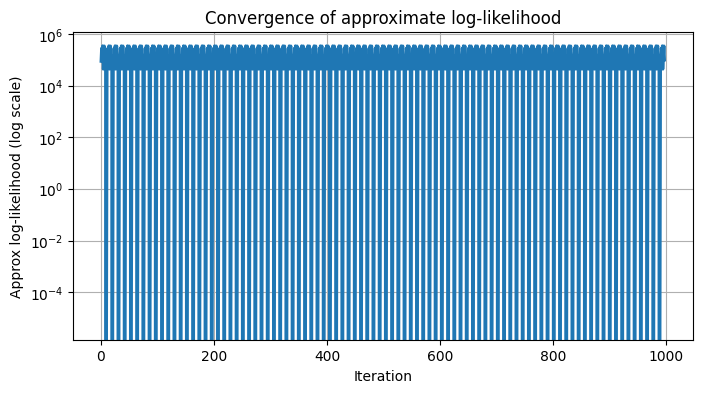

Text(0, 0.5, 'theta[2]')

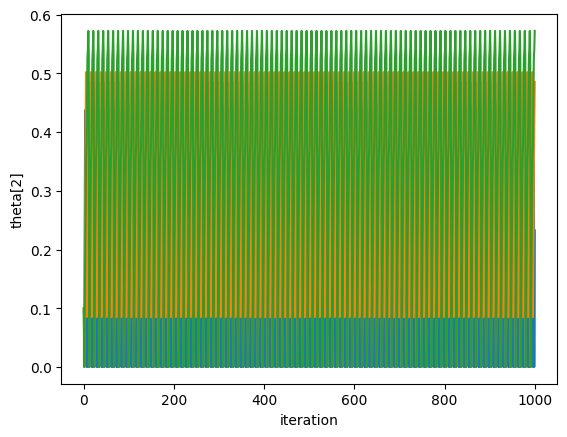

In [48]:

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(loglik_hist[2:], lw=2)
plt.yscale("log")   # <-- this is the correct way
plt.xlabel("Iteration")
plt.ylabel("Approx log-likelihood (log scale)")
plt.title("Convergence of approximate log-likelihood")
plt.grid(True)
plt.show()


# plot evolution of a specific parameter j
j = 2 # e.g. first μ
plt.figure()
plt.plot(mu_iterates[:, 0])
plt.plot(mu_iterates[:, 1])
plt.plot(mu_iterates[:, 2])
plt.xlabel("iteration")
plt.ylabel(f"theta[{j}]")


In [ ]:
mu_hat

array([0.93703099, 0.03984627, 0.05282532])

In [ ]:
phi_hat[3,0,:]

array([0.07255431, 0.0245995 , 0.01335647])

In [ ]:
np.sum(np.abs(phi_true -phi_hat))/(num_comm**2*p)

np.float64(0.05529807126486117)

In [ ]:
mu_hat

array([0.93703099, 0.03984627, 0.05282532])

# Some plotting

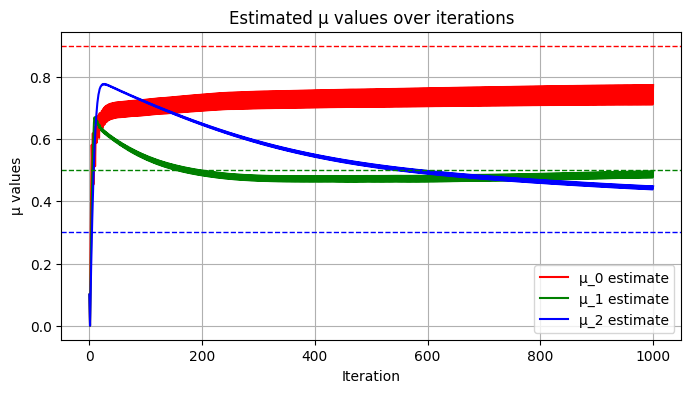

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

true_mu = np.array([0.9, 0.5, 0.3])
num_comm = len(true_mu)
colors = ['r', 'g', 'b']

plt.figure(figsize=(8,4))

for h in range(num_comm):
    plt.plot(mu_iterates[:, h], label=f"μ_{h} estimate", color=colors[h])

# plot true value as horizontal lines
for h in range(num_comm):
    plt.axhline(true_mu[h], color=colors[h], linestyle='--', linewidth=1)

plt.xlabel("Iteration")
plt.ylabel("μ values")
plt.title("Estimated μ values over iterations")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
num_params_mu = num_comm
num_params_phi = num_comm * num_comm * p

# extract all φ parameter vectors over iterations

# reconstruct phi for each iteration
phi_path = np.array([
    phi_param_vector_to_tensor(phi_iterates[it, :], num_comm, p)
    for it in range(phi_iterates.shape[0])
]) 


print(phi_path.shape)

(1001, 90)
(1001, 10, 3, 3)


In [ ]:
print(phi_iterates.shape)

(1001, 10, 3, 3)


0.5458775937413701
0.18393972058572117
0.45


/var/folders/dr/dsd8dmz50511xd_z7s87pr9m0000gp/T/ipykernel_65838/74026323.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_comm * 2)


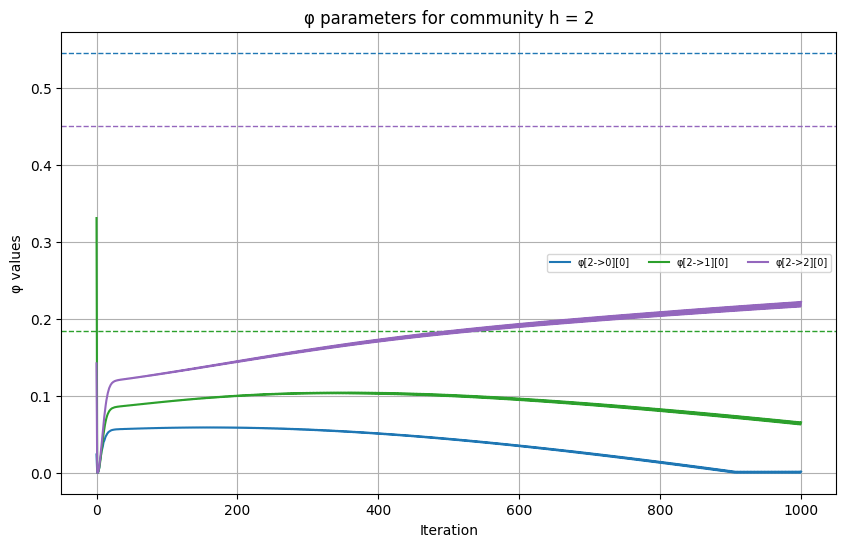

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

h = 2 # community one
plt.figure(figsize=(10,6))

# get a colormap with enough distinct colors
cmap = plt.cm.get_cmap("tab20", num_comm * 2)

color_index = 0

for r in range(num_comm):
    for m in range(1):
        color = cmap(color_index)
        color_index += 1

        # estimated trajectory
        plt.plot(
            phi_iterates[:, m, h, r],
            label=f"φ[{h}->{r}][{m}]",
            color=color
        )

        # true value (same color, dashed)
        plt.axhline(
            phi_true[m, h, r],
            linestyle="--",
            linewidth=1,
            color=color
        )
        print(phi_true[m, h, r])

plt.xlabel("Iteration")
plt.ylabel("φ values")
plt.title(f"φ parameters for community h = {h}")
plt.legend(ncol=4, fontsize=7)
plt.grid(True)
plt.show()


# Approach 2

In [ ]:
final_time = 100
num_nodes1 = 500
num_nodes2 = 5000
alphas =  np.array([0.5,0.3,0.2]) 
comm_size1 = (num_nodes1 * alphas).astype(int)
comm_size2 = (num_nodes2 * alphas).astype(int)

#Dissociative
# prob_matrix = np.array([[0.1, 0.9, 0.7],
#                                [0.9, 0.1, 0.9],
#                                [0.7, 0.9, 0.1]])

#Assertative
prob_matrix = np.array([[0.9, 0.2, 0.1],
                               [0.2, 0.9, 0.3],
                               [0.1, 0.3, 0.9]])

def psi(x):
    return x

In [ ]:
power_params =  [0.9, 2.5]
ray_params = [0.5, 1.0]
exp_params = [0.9, 0.5]


# exp_params1 =  [1.5, 10]
# exp_params2 = [1.5,2]
# exp_params3 = [1.5, 0.5]

kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_function_matrix = np.array([exponential_kernel, rayleigh_kernel, power_law_kernel])


labs, adj_matrix = generate_sbm_adjacency_matrix(comm_size2, prob_matrix)
E = np.random.exponential(scale = 1.0, size = (final_time, num_nodes2, 100))
N_comb, lmbd_comb ,X_comb ,kernel_values = simulate_comb_sbm(E, final_time,num_nodes2,comm_size2, kernel_function_matrix, kernel_params_matrix, adj_matrix, labs, mu_vector = np.array([0.9, 0.5, 0.3]))
N_mf, lmbd_mf, X_mf, kernel_values = simulate_mf_sbm(E, final_time, comm_size2, prob_matrix, kernel_function_matrix, kernel_params_matrix)

[[0.5 0.5 0.5]]
[[0.54587759 0.18393972 0.45      ]]
[[0.5 0.5 0.5]]
[[0.54587759 0.18393972 0.45      ]]
[[0.5 0.5 0.5]]
[[0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]]
[[0.3310915  0.01831564 0.13519899]
 [0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]]
[[0.3310915  0.01831564 0.13519899]
 [0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]]
[[0.3310915  0.01831564 0.13519899]
 [0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]
 [0.74315542 0.60090504 0.59346213]]
[[2.00817144e-01 1.85114706e-04 5.42545931e-02]
 [3.31091497e-01 1.83156389e-02 1.35198994e-01]
 [5.45877594e-01 1.83939721e-01 4.50000000e-01]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]
 [0.74315542 0.60090504 0.59346213]]
[[2.00817144e-01 1.85114706e-04 5.425459

In [ ]:
num_comm = len(alphas)
p = 5    # choose small number of lags

In [ ]:
def index_to_jm(a, p):
    a0 = a - 1
    j = a0 // p          # 0..N-1
    m = a0 % p +1       # 1..p
    return j, m

In [ ]:
def compute_d(X, adj_matrix, p):
    T, N = X.shape
    Np = N * p
    d = np.zeros((N, Np + 1))
    d[:, 0] = T

    for a in range(1, Np + 1):
        j_a, m_a = index_to_jm(a, p)
        s = np.sum(X[:T-(m_a-1), j_a])
        d[:, a] = adj_matrix[j_a, :] * s

    return d

In [ ]:
d= compute_d(X_comb, adj_matrix, p)


In [ ]:
def compute_k(X, adj_matrix, p):
    T, N = X.shape
    Np = N * p
    k = np.zeros((N, Np + 1))

    k[:, 0] = X.sum(axis=0)

    for a in range(1, Np + 1):
        j_a, m_a = index_to_jm(a, p)
        if m_a >= T:
            continue
        Y_t = X[m_a:, :]
        Y_lag = X[:T- m_a, j_a]
        contrib = np.sum(Y_t * Y_lag[:, np.newaxis], axis=0)
        k[:, a] = adj_matrix[j_a, :] * contrib

    return k

In [ ]:
k = compute_k(X_comb, adj_matrix, p)

print(k.shape)
print(k[:, 0])

(5000, 25001)
[219. 231. 228. ...  54.  56.  64.]


In [ ]:
def compute_J(X, adj_matrix, p):
    T, N = X.shape
    Np = N * p
    J = np.zeros((N, Np + 1, Np + 1))

    for i in range(N):
        y_i = X[:, i]
        J[i, 0, 0] = y_i.sum()
        
        for a in range(1, Np + 1):
            for b in range(1, Np + 1):
                j_a, m_a = index_to_jm(a, p)
                j_b, m_b = index_to_jm(b, p)
                J[i,a, 0] = adj_matrix[j_a, i] * np.sum(y_i[m_a:] * X[:T - m_a, j_a])
                J[i,0, b] = adj_matrix[j_b, i] * np.sum(y_i[m_b:] * X[:T - m_b, j_b])
                J[i, a, b] = adj_matrix[j_a, i] * adj_matrix[j_b, i] * np.sum(y_i[max(m_a, m_b):] * X[:T - max(m_a, m_b), j_a] * X[:T - max(m_a, m_b), j_b])
    return J


In [ ]:
def compute_Jh_aggregated(X, adj_matrix, p, labs, comm_sizes):
    """
    Compute community-level J^h matrices directly, without storing J^i for all i.

    X          : (T, N)
    adj_matrix : (N, N)
    p          : int
    labs       : (N,) community labels in {0,...,q-1}
    Lambda_bar : (N,) node-level Λ̄^i (whatever definition you use in approach 2)

    Returns
    -------
    Jh_list : list of length q, each element is (Np+1, Np+1) array J^h
    """
    X = np.asarray(X)
    adj_matrix = np.asarray(adj_matrix)
    labs = np.asarray(labs)
    Abar = jumps_per_community_over_time(labs, X).mean(axis=0)/comm_sizes

    T, N = X.shape
    Np = N * p
    q = labs.max() + 1

    Jh_list = [np.zeros((Np + 1, Np + 1)) for _ in range(q)]

    # precompute mapping a -> (j_a, m_a)
    a_to_j = np.empty(Np + 1, dtype=int)
    a_to_m = np.empty(Np + 1, dtype=int)
    a_to_j[0] = -1
    a_to_m[0] = 0
    for a in range(1, Np + 1):
        j_a, m_a = index_to_jm(a, p)
        a_to_j[a] = j_a
        a_to_m[a] = m_a

    for i in range(N):
        h = labs[i]

        # build J_i on the fly, but never store all J
        Ji = np.zeros((Np + 1, Np + 1))
        y_i = X[:, i]

        Ji[0, 0] = y_i.sum()

        # J^{ia0} and J^{i0a}
        for a in range(1, Np + 1):
            j_a = a_to_j[a]
            m_a = a_to_m[a]
            if m_a >= T:
                continue
            L = T - m_a
            Y_t = X[m_a:, i]          # (L,)
            Y_lag = X[:L, j_a]        # (L,)
            contrib = np.sum(Y_t * Y_lag)
            val = adj_matrix[j_a, i] * contrib
            Ji[a, 0] = val
            Ji[0, a] = val

        # J^{iab}, a,b >=1
        for a in range(1, Np + 1):
            j_a = a_to_j[a]; m_a = a_to_m[a]
            for b in range(1, Np + 1):
                j_b = a_to_j[b]; m_b = a_to_m[b]
                s = max(m_a, m_b)
                if s >= T:
                    continue
                L = T - s
                Y_t   = X[s:, i]               # (L,)
                Y_a_l = X[:L, j_a]             # (L,)
                Y_b_l = X[:L, j_b]             # (L,)
                contrib = np.sum(Y_t * Y_a_l * Y_b_l)
                Ji[a, b] = adj_matrix[j_a, i] * adj_matrix[j_b, i] * contrib

        # accumulate into the community h
        Jh_list[h] += Ji / Abar[h]**2

    return Jh_list


In [ ]:
import numpy as np

def compute_Ji_single(i, X, adj_matrix, p, js, ms, dtype=np.float64):
    """
    Compute J^i (Np+1 x Np+1) for a single node i as efficiently as possible,
    assuming the same definition as in your original compute_J:

        - a in {1,...,Np} corresponds to (j_a, m_a) via js[a], ms[a]
        - J_i[0,0] = sum_t y_i(t)
        - J_i[a,0] = adj[j_a, i] * sum_{t=m_a}^{T-1} y_i(t) X_{t-m_a, j_a}
        - J_i[a,b] = adj[j_a, i] * adj[j_b, i] *
                     sum_{t=m}^{T-1} y_i(t) X_{t-m, j_a} X_{t-m, j_b}
                     where m = max(m_a, m_b)

    This implementation:
      - removes loops over (a,b)
      - does heavy work via per-lag matrix multiplications
      - uses advanced indexing to build the (Np x Np) block.

    Parameters
    ----------
    i          : int, target node index
    X          : ndarray, shape (T, N)
    adj_matrix : ndarray, shape (N, N)
    p          : int, number of lags
    js, ms     : arrays of length Np+1 mapping index a -> (j_a, m_a)
                 js[0], ms[0] are dummy and ignored; a>=1 used.
    dtype      : numpy dtype for J_i

    Returns
    -------
    J_i : ndarray, shape (Np+1, Np+1)
    """
    X = np.asarray(X)
    adj_matrix = np.asarray(adj_matrix)
    T, N = X.shape
    Np = N * p

    # Output
    J_i = np.zeros((Np + 1, Np + 1), dtype=dtype)

    # Extract time series and adjacency column for node i
    y_i = X[:, i].astype(dtype, copy=False)        # (T,)
    col_adj = adj_matrix[:, i].astype(dtype, copy=False)  # (N,)

    # (0,0) entry
    J_i[0, 0] = y_i.sum()

    # Precompute number of usable lags (if p > T-1, larger lags give zero)
    m_max = min(p, T - 1)

    # ---- 1. Precompute B[m, j] and C[m, j, k] for m=1..m_max ----
    # B[m, j] = sum_{t=m}^{T-1} y_i(t) X_{t-m, j}
    # C[m, j, k] = sum_{t=m}^{T-1} y_i(t) X_{t-m, j} X_{t-m, k}
    B = np.zeros((p + 1, N), dtype=dtype)          # index 1..p used
    C = np.zeros((p + 1, N, N), dtype=dtype)       # index 1..p used

    for m in range(1, m_max + 1):
        # y part: y_i[m:] has length T - m
        y_tail = y_i[m:]              # (T-m,)
        # X part: X[:T-m, :] has shape (T-m, N)
        X_head = X[:T - m, :].astype(dtype, copy=False)

        # B_m(j) = sum_{t=m}^{T-1} y_i(t) X_{t-m, j}
        #        = y_tail^T @ X_head
        B[m] = y_tail @ X_head        # (N,)

        # For C_m: define Z_m[t, j] = sqrt(y_i[t+m]) * X_{t, j}
        # Then C_m = Z_m^T Z_m
        sqrt_y_tail = np.sqrt(y_tail, dtype=dtype)[:, None]   # (T-m, 1)
        Z_m = X_head * sqrt_y_tail                            # (T-m, N)
        C[m] = Z_m.T @ Z_m                                    # (N, N)

    # ---- 2. First row/column J_i[a,0], J_i[0,a] (a>=1) ----
    js1 = js[1:]      # (Np,)
    ms1 = ms[1:]      # (Np,)

    # adjacency factors adj[j_a, i] for all a
    adj_js1 = col_adj[js1]              # (Np,)

    # B_for_a[a] = B[m_a, j_a]
    B_for_a = B[ms1, js1]               # (Np,)

    J_a0 = adj_js1 * B_for_a            # (Np,)
    J_i[1:, 0] = J_a0
    J_i[0, 1:] = J_a0

    # ---- 3. Main block J_i[a,b] for a,b >= 1 ----
    # lag index matrix: M[a,b] = max(m_a, m_b)
    M_idx = np.maximum.outer(ms1, ms1)   # (Np, Np), entries in {1..p}

    # j indices matrix:
    j_a_idx = np.broadcast_to(js1[:, None], (Np, Np))  # (Np, Np)
    j_b_idx = np.broadcast_to(js1[None, :], (Np, Np))  # (Np, Np)

    # base[a,b] = C[M[a,b], j_a, j_b]
    base = C[M_idx, j_a_idx, j_b_idx]                # (Np, Np)

    # adjacency outer product: adj[j_a, i] * adj[j_b, i]
    adj_outer = np.outer(adj_js1, adj_js1)           # (Np, Np)

    J_block = adj_outer * base                       # (Np, Np)

    J_i[1:, 1:] = J_block

    return J_i


def compute_Jh_aggregated(X, adj_matrix, p, labs, comm_sizes,
                          Lambda_bar=None, dtype=np.float64):
    X = np.asarray(X)
    adj_matrix = np.asarray(adj_matrix)
    labs = np.asarray(labs)

    T, N = X.shape
    Np = N * p
    q = labs.max() + 1

    # ---- compute Λ̄^i (node-level) or use approximation ----
    if Lambda_bar is None:
        # Your community-level average intensity:
        # Abar[h] = average jumps per node in community h
        # (we assume you have this function already implemented)
        jumps_comm_t = jumps_per_community_over_time(labs, X)  # shape (T, q)
        Abar_comm = jumps_comm_t.mean(axis=0) / comm_sizes     # shape (q,)

        # Approximate node-level Λ̄^i by its community average:
        Lambda_bar = Abar_comm[labs]                           # shape (N,)

    Lambda_bar = np.asarray(Lambda_bar, dtype=dtype)
    weights = 1.0 / (Lambda_bar**2)                            # (N,)

    # ---- allocate one matrix per community ----
    Jh_list = [np.zeros((Np + 1, Np + 1), dtype=dtype) for _ in range(q)]

    # ---- precompute index -> (j, m) mapping (shared for all i) ----
    js = np.empty(Np + 1, dtype=int)
    ms = np.empty(Np + 1, dtype=int)
    js[0] = 0
    ms[0] = 0
    for a in range(1, Np + 1):
        j, m = index_to_jm(a, p)
        js[a] = j
        ms[a] = m

    # ---- main streaming loop over nodes i ----
    for i in range(N):
        J_i = compute_Ji_single(i, X, adj_matrix, p, js, ms, dtype=dtype)
        print(i)
        h = labs[i]
        Jh_list[h] += weights[i] * J_i   # accumulate weighted contribution

    return Jh_list


In [ ]:
J = compute_Jh_aggregated(X_comb, adj_matrix, p, labs, comm_size2)

0


: 

In [ ]:
import seaborn as sns
def build_M(comm_sizes, p):
    """
    comm_sizes: iterable of community sizes (n1, n2, ..., nq)
    p: number of lags
    returns M of shape (1 + p * sum(comm_sizes), 1 + p * len(comm_sizes))
    """
    comm_sizes = np.asarray(comm_sizes)
    q = len(comm_sizes)
    N = comm_sizes.sum()

    rows = 1 + N * p
    cols = 1 + q * p
    M = np.zeros((rows, cols))

    M[0, 0] = 1.0

    row_offset = 1
    for h, n_h in enumerate(comm_sizes):
        block_rows = n_h * p
        block_cols = p
        col_offset = 1 + h * p

        block = np.vstack([np.eye(p)] * n_h) # shape (n_h*p, p)
        print(block.shape)
        print(block)
        sns.heatmap(block)
        M[row_offset:row_offset + block_rows,
          col_offset:col_offset + block_cols] = block

        row_offset += block_rows

    return M


(25000, 10)
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
(15000, 10)
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
(10000, 10)
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
(50001, 31)


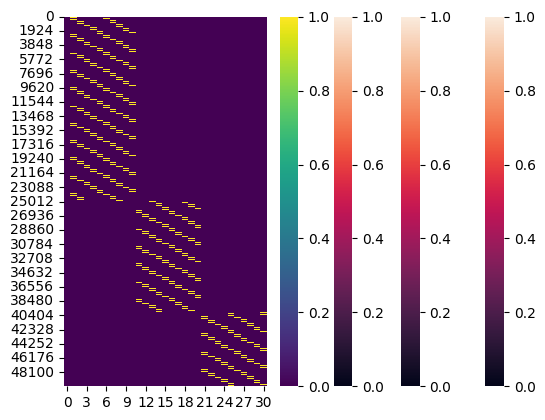

In [ ]:
p = 10
M = build_M(comm_size2,p)


sns.heatmap(M, cmap="viridis")
print(M.shape)

In [ ]:
def compute_nu(X_comb, adj_matrix, p, labs, comm_sizes):
    d = compute_d(X_comb, adj_matrix, p)
    k = compute_k(X_comb, adj_matrix, p)
    J_list = compute_Jh_aggregated(X_comb, adj_matrix, p, labs)
    M = build_M(comm_sizes)

    num_comm = len(J_list)
    #num_params = num_comm * num_comm**2 * p
    nu_list = []
    start = 0
    A_bar = jumps_per_community_over_time(labs, X).mean(axis=0)/comm_sizes
    for h in range(num_comm):
        size = comm_sizes[h]
        g_h = M.T @ np.sum(d[start: start+size,:], axis=0)
        s_h = M.T @ np.sum(k[start:start+size, :], axis = 0)/A_bar[h]
        J_h = M.T @ J_list[h] @ M

        nu_h = np.linalg.inv(J_h) @ (g_h - 2 * s_h)
        nu_list.append(nu_h)

    return nu_list


In [ ]:
def compute_nu_given_inputs(d, k, J_list, M):
    num_comm = len(J_list)
    #num_params = num_comm * num_comm**2 * p
    nu_list = []
    start = 0
    A_bar = jumps_per_community_over_time(labs, X).mean(axis=0)/comm_sizes
    for h in range(num_comm):
        size = comm_sizes[h]
        g_h = M.T @ np.sum(d[start: start+size,:], axis=0)
        s_h = M.T @ np.sum(k[start:start+size, :], axis = 0)/A_bar[h]
        J_h = M.T @ J_list[h] @ M

        nu_h = np.linalg.inv(J_h) @ (g_h - 2 * s_h)
        nu_list.append(nu_h)

    return nu_list

In [ ]:
final_time = 100
num_nodes1 = 500
num_nodes2 = 5000
alphas =  np.array([0.5,0.3,0.2]) 
comm_size1 = (num_nodes1 * alphas).astype(int)
comm_size2 = (num_nodes2 * alphas).astype(int)

#Dissociative
# prob_matrix = np.array([[0.1, 0.9, 0.7],
#                                [0.9, 0.1, 0.9],
#                                [0.7, 0.9, 0.1]])

#Assertative
prob_matrix = np.array([[0.9, 0.2, 0.1],
                               [0.2, 0.9, 0.3],
                               [0.1, 0.3, 0.9]])

def psi(x):
    return x

In [ ]:
power_params =  [0.9, 2.5]
ray_params = [0.5, 1.0]
exp_params = [0.9, 0.5]


# exp_params1 =  [1.5, 10]
# exp_params2 = [1.5,2]
# exp_params3 = [1.5, 0.5]

kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_function_matrix = np.array([exponential_kernel, rayleigh_kernel, power_law_kernel])


labs, adj_matrix = generate_sbm_adjacency_matrix(comm_size1, prob_matrix)
E = np.random.exponential(scale = 1.0, size = (final_time, num_nodes1, 100))
N_comb, lmbd_comb ,X_comb ,kernel_values = simulate_comb_sbm(E, final_time,num_nodes1,comm_size1, kernel_function_matrix, kernel_params_matrix, adj_matrix, labs, mu_vector = np.array([0.9, 0.5, 0.3]))
N_mf, lmbd_mf, X_mf, kernel_values = simulate_mf_sbm(E, final_time, comm_size1, prob_matrix, kernel_function_matrix, kernel_params_matrix)

[[0.5 0.5 0.5]]
[[0.54587759 0.18393972 0.45      ]]
[[0.5 0.5 0.5]]
[[0.54587759 0.18393972 0.45      ]]
[[0.5 0.5 0.5]]
[[0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]]
[[0.3310915  0.01831564 0.13519899]
 [0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]]
[[0.3310915  0.01831564 0.13519899]
 [0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]]
[[0.3310915  0.01831564 0.13519899]
 [0.54587759 0.18393972 0.45      ]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]
 [0.74315542 0.60090504 0.59346213]]
[[2.00817144e-01 1.85114706e-04 5.42545931e-02]
 [3.31091497e-01 1.83156389e-02 1.35198994e-01]
 [5.45877594e-01 1.83939721e-01 4.50000000e-01]]
[[0.5        0.5        0.5       ]
 [0.63284065 0.56562574 0.56242423]
 [0.74315542 0.60090504 0.59346213]]
[[2.00817144e-01 1.85114706e-04 5.425459

In [ ]:
p = 5

d = compute_d(X_comb, adj_matrix, p)
print("d computed")
k = compute_k(X_comb, adj_matrix, p)
print("k computed")
J_list = compute_Jh_aggregated(X_comb, adj_matrix, p, labs, comm_size1)
print("J list computed")
M = build_M(comm_size1, p)
print("M computed")

print("Starting mu computation")
mus = compute_nu_given_inputs(d, k, J_list, M)

d computed
k computed


KeyboardInterrupt: 